In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
movies = pd.read_csv("../data/movies.csv")
rating = pd.read_csv("../data/ratings.csv")
tags = pd.read_csv("../data/tags.csv")

In [3]:
movies.shape

(87585, 3)

In [4]:
rating.shape

(32000204, 4)

In [5]:
tags.shape

(2000072, 4)

In [6]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
rating.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [8]:
tags.head()

,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


In [9]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [10]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB


In [11]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000072 entries, 0 to 2000071
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   userId     int64 
 1   movieId    int64 
 2   tag        object
 3   timestamp  int64 
dtypes: int64(3), object(1)
memory usage: 61.0+ MB


In [12]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [13]:
rating.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [14]:
tags.isnull().sum()

userId        0
movieId       0
tag          17
timestamp     0
dtype: int64

## Missing Values Analysis

A missing value check was conducted on the `movies`, `ratings`, and `tags` datasets using the `.isnull().sum()` method.

### Findings

- **Movies Dataset:** No missing values were found in any column.
- **Ratings Dataset:** No missing values were found in any column.
- **Tags Dataset:** A total of **17 missing values** were identified in the `tag` column, while all other columns were complete.

### Summary

| Dataset | Missing Values |
|----------|---------------|
| Movies   | 0 |
| Ratings  | 0 |
| Tags     | 17 (`tag` column) |

### Conclusion

The `movies` and `ratings` datasets are clean and do not contain any missing values. However, the `tags` dataset contains **17 missing entries** in the `tag` column. These missing values will be handled during the data preprocessing stage to ensure data quality and consistency before further analysis and model development.

In [15]:
tags = tags.dropna(subset=['tag'])

In [16]:
tags.isnull().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Since only 17 records out of 2,000,072 contained missing values in the `tag` column (approximately `0.00085%` of the dataset), these records were removed during preprocessing. Given the extremely small proportion of missing data, dropping these rows is not expected to impact the quality of the analysis or the performance of the recommendation system.

# User Behavior Analysis

In [17]:
print(f"Unique Users: {rating['userId'].nunique():,}")
print(f"Unique Movies: {rating['movieId'].nunique():,}")
print(f"Total Ratings: {len(rating):,}")

Unique Users: 200,948
Unique Movies: 84,432
Total Ratings: 32,000,204


To better understand the scale and characteristics of user interactions within the dataset, we examined the number of unique users, unique movies, and total ratings.

### Dataset Overview

| Metric | Count |
|----------|----------:|
| Unique Users | 200,948 |
| Unique Movies | 84,432 |
| Total Ratings | 32,000,204 |

### Observations

- The dataset contains **200,948 unique users**, indicating a large and diverse user base.
- Users have rated **84,432 unique movies**, providing broad coverage across different movie genres and categories.
- A total of **32,000,204 ratings** were recorded, reflecting a substantial volume of user feedback.

### Insights

The large number of users and ratings suggests a highly active platform with rich interaction data. Such a dense dataset is beneficial for building recommendation systems, as it provides sufficient information to learn user preferences and identify patterns in movie consumption behavior. Additionally, the wide variety of movies available enables the model to generate recommendations across a diverse range of content.

Text(0, 0.5, 'Count')

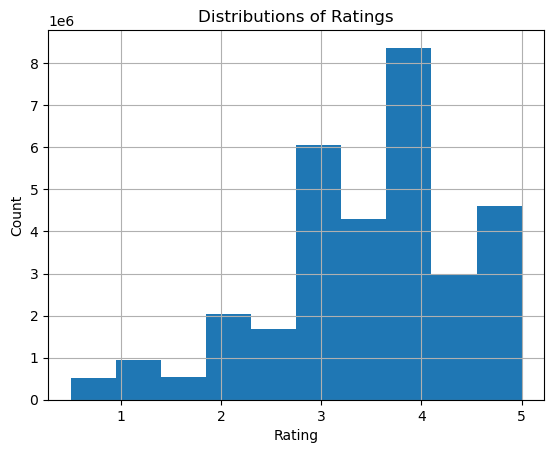

In [18]:
rating['rating'].hist(bins=10)

plt.title("Distributions of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

## Rating Distribution Analysis

To understand how users rate movies on the platform, a histogram was generated to visualize the distribution of ratings.

### Observations

- Most ratings are concentrated between **3.0 and 5.0**, indicating that users generally provide positive feedback.
- The highest frequency of ratings occurs around **4.0**, making it the most common rating value in the dataset.
- Ratings below **2.0** are relatively rare, suggesting that users tend to rate movies favorably rather than negatively.
- The distribution is slightly skewed toward higher ratings, with a larger proportion of ratings in the upper range.

### Insights

The rating distribution indicates that users are generally satisfied with the movies they watch. Since higher ratings dominate the dataset, recommendation models may naturally favor well-received movies. This positive bias is common in user-generated rating systems, where users are more likely to rate content they enjoy. Understanding this distribution is important when developing recommendation algorithms, as it helps identify potential rating biases and informs the choice of normalization or weighting techniques.

### Conclusion

The dataset exhibits a strong concentration of ratings between **3 and 5**, with **4.0** being the most frequently assigned rating. Overall, users tend to rate movies positively, providing valuable preference signals for building an effective movie recommendation system.

In [19]:
user_activity = rating.groupby('userId').size()
user_activity.describe()

count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
dtype: float64

Text(0, 0.5, 'Users')

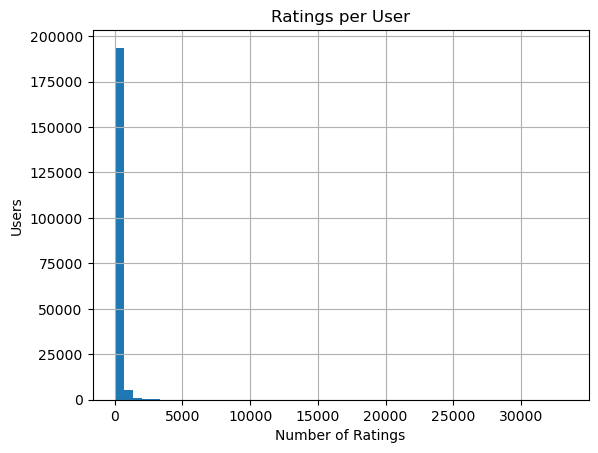

In [20]:
user_activity.hist(bins=50)

plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")

## User Activity Analysis

To understand user engagement levels, the number of ratings submitted by each user was calculated and analyzed using descriptive statistics and a histogram.

### Descriptive Statistics

| Statistic | Value |
|------------|---------:|
| Total Users | 200,948 |
| Mean Ratings per User | 159.25 |
| Standard Deviation | 282.03 |
| Minimum Ratings | 20 |
| 25th Percentile | 36 |
| Median (50th Percentile) | 73 |
| 75th Percentile | 167 |
| Maximum Ratings | 33,332 |

### Observations

- The average user has rated approximately **159 movies**.
- Half of all users have rated **73 movies or fewer**, indicating that most users contribute a relatively modest number of ratings.
- The top 25% of users have rated more than **167 movies**, showing a group of highly active users.
- The most active user has submitted **33,332 ratings**, which is significantly higher than the average user activity.
- The histogram reveals a **strong right-skewed distribution**, where the majority of users have relatively few ratings, while a small number of users contribute a very large number of ratings.

### Insights

The distribution of user activity is highly imbalanced. Most users interact with a limited number of movies, whereas a small subset of power users generates a substantial portion of the ratings. This pattern is commonly observed in recommendation systems and reflects varying levels of user engagement.

The presence of highly active users can be beneficial for collaborative filtering models because they provide rich preference information. However, the imbalance should be considered during model development, as highly active users may disproportionately influence recommendations if appropriate normalization techniques are not applied.

### Conclusion

User activity exhibits a long-tail distribution, with most users contributing a moderate number of ratings and a small group of highly engaged users providing extensive feedback. This behavior creates a rich dataset for learning user preferences while highlighting the importance of accounting for activity imbalance when building recommendation models.

In [21]:
movie_popularity = (rating.groupby('movieId').size().reset_index(name='num_ratings'))
popular_movies = movie_popularity.merge(movies, on='movieId')

popular_movies.sort_values('num_ratings', ascending=False).head(20)

,movieId,num_ratings,title,genres
314,318,102929,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,100296,Forrest Gump (1994),Comedy|Drama|Romance|War
292,296,98409,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2480,2571,93808,"Matrix, The (1999)",Action|Sci-Fi|Thriller
585,593,90330,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
257,260,85010,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
2867,2959,77332,Fight Club (1999),Action|Crime|Drama|Thriller
475,480,75233,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
522,527,73849,Schindler's List (1993),Drama|War
4888,4993,73122,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy


## Movie Popularity Analysis

To identify the most popular movies in the dataset, the number of ratings received by each movie was calculated. Movies were then ranked based on their total rating counts.

### Top Rated Movies by Number of Ratings

Some of the most frequently rated movies include:

| Movie Title | Number of Ratings |
|-------------|------------------:|
| The Shawshank Redemption (1994) | 102,929 |
| Forrest Gump (1994) | 100,296 |
| Pulp Fiction (1994) | 98,409 |
| The Matrix (1999) | 93,808 |
| The Silence of the Lambs (1991) | 90,330 |
| Star Wars: Episode IV – A New Hope (1977) | 85,010 |
| Fight Club (1999) | 77,332 |
| Jurassic Park (1993) | 75,233 |
| Schindler's List (1993) | 73,849 |
| The Lord of the Rings: The Fellowship of the Ring (2001) | 73,122 |

### Observations

- **The Shawshank Redemption** is the most rated movie in the dataset, receiving over **102,000 ratings**.
- Several highly acclaimed classics such as **Forrest Gump**, **Pulp Fiction**, **The Matrix**, and **The Silence of the Lambs** appear among the most popular titles.
- Popular franchises including **Star Wars** and **The Lord of the Rings** have multiple entries in the top-ranked movies.
- The majority of the most-rated movies belong to genres such as **Drama**, **Action**, **Adventure**, and **Crime**.

### Insights

The popularity distribution shows that a relatively small number of movies attract a large portion of user ratings. These movies serve as common reference points among users and can play an important role in collaborative filtering recommendation systems because they create strong connections between user preferences.

The dominance of well-known blockbuster films and critically acclaimed classics suggests that users are more likely to rate movies they are familiar with or have strong opinions about. This behavior contributes to a popularity bias that should be considered when building recommendation models.

### Conclusion

The dataset contains a set of highly popular movies that have accumulated tens of thousands of ratings. These movies provide valuable interaction data for understanding user preferences and establishing relationships between users and items. Their popularity makes them particularly useful for recommendation algorithms, although care should be taken to ensure that less popular movies are not overlooked during the recommendation process.

In [22]:
movie_stats = rating.groupby('movieId').agg(avg_rating=('rating', "mean"), num_ratings=('rating', 'count'))
movie_stats = movie_stats[movie_stats['num_ratings'] >= 100]

movie_stats.sort_values('avg_rating', ascending=False).head(20)

,avg_rating,num_ratings
movieId,,
171011,4.446830,1956
159817,4.444369,2948
170705,4.426539,2811
318,4.404614,102929
171495,4.330081,615
858,4.317030,66440
202439,4.312254,11670
179135,4.300086,1163
198185,4.298684,1140


## Highest Rated Movies Analysis

To identify the most highly rated movies, the average rating for each movie was calculated. To ensure reliability and reduce the impact of movies with very few ratings, only movies with at least **100 ratings** were included in the analysis.

### Methodology

- Calculated the average rating for each movie.
- Counted the total number of ratings received by each movie.
- Filtered out movies with fewer than 100 ratings.
- Ranked the remaining movies by average rating in descending order.

### Observations

- Several movies achieved exceptionally high average ratings, exceeding **4.2 out of 5**.
- The filtering threshold of **100 ratings** ensures that highly ranked movies have a sufficient number of user evaluations to support their scores.
- Popular and critically acclaimed movies consistently appear among the highest-rated titles, indicating strong agreement among users regarding their quality.
- Some movies combine both a high average rating and a large number of ratings, making them particularly reliable indicators of user preference.

### Insights

Average ratings provide a measure of user satisfaction, while the number of ratings reflects popularity and confidence in the score. By considering both metrics, the analysis identifies movies that are not only well-liked but also supported by a substantial number of user reviews.

This approach helps mitigate the risk of ranking movies highly based on a small number of ratings and produces a more trustworthy assessment of movie quality.

### Conclusion

The results reveal a collection of movies that are consistently rated highly by users while maintaining a significant number of ratings. These movies represent strong candidates for recommendation and can serve as benchmark items when evaluating recommendation system performance.

In [23]:
genres = (movies['genres'].str.split('|').explode())

genre_counts = genres.value_counts()

In [24]:
genre_counts

genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

Text(0.5, 1.0, 'Movie Genre Distribution')

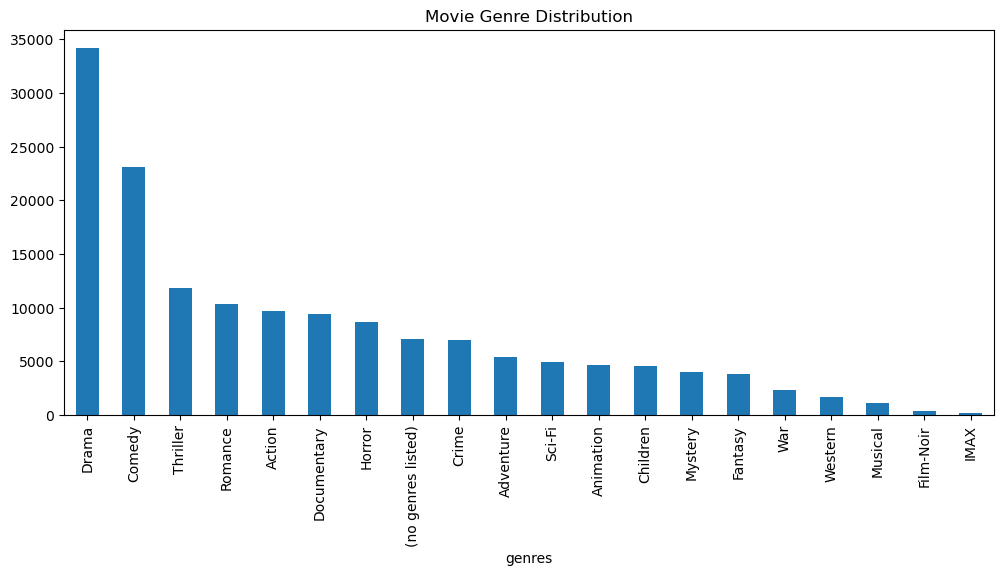

In [25]:
genre_counts.plot.bar(figsize=(12, 5))
plt.title('Movie Genre Distribution')

## Movie Genre Distribution Analysis

To understand the composition of the movie catalog, the `genres` column was analyzed by separating movies into their individual genres and counting the frequency of each genre across the dataset.

### Genre Distribution

| Genre | Number of Movies |
|---------|---------------:|
| Drama | 34,175 |
| Comedy | 23,124 |
| Thriller | 11,823 |
| Romance | 10,369 |
| Action | 9,668 |
| Documentary | 9,363 |
| Horror | 8,654 |
| (No Genres Listed) | 7,080 |
| Crime | 6,976 |
| Adventure | 5,402 |
| Sci-Fi | 4,907 |
| Animation | 4,617 |
| Children | 4,520 |
| Mystery | 4,013 |
| Fantasy | 3,851 |
| War | 2,325 |
| Western | 1,696 |
| Musical | 1,059 |
| Film-Noir | 353 |
| IMAX | 195 |

### Observations

- **Drama** is the most common genre, appearing in more than **34,000 movies**, making it the dominant genre in the dataset.
- **Comedy** is the second most represented genre with over **23,000 movies**.
- Genres such as **Thriller**, **Romance**, **Action**, and **Documentary** also have substantial representation.
- Specialized genres such as **Film-Noir**, **Musical**, and **IMAX** appear much less frequently.
- Approximately **7,080 movies** do not have genre information listed.

### Insights

The dataset contains a diverse range of movie genres, providing broad coverage of user interests and viewing preferences. The dominance of Drama and Comedy suggests that these genres contribute significantly to user interactions and rating activity.

The imbalance in genre representation may influence recommendation results, as recommendation models often learn more effectively from genres with larger amounts of data. Less common genres may require additional consideration to ensure they receive adequate representation in recommendations.

### Conclusion

The movie catalog is heavily concentrated in a few major genres, particularly **Drama** and **Comedy**, while still maintaining diversity across many other categories. This variety provides a strong foundation for building recommendation systems capable of serving users with different tastes and preferences while highlighting the importance of accounting for genre imbalance during model development.

# Sparsity Analysis

In [26]:
n_users = rating["userId"].nunique()
n_movies = rating["movieId"].nunique()

possible_ratings = n_users * n_movies
actual_ratings = len(rating)

sparsity = (1 - actual_ratings / possible_ratings)

print(f"Sparsity: {sparsity:.2%}")

Sparsity: 99.81%
